# Objetivo: Transformar dados brutos em estratégia de retenção

## 1. Introdução e Contextualização Estratégica
### 1.1 O Imperativo do Negócio na Era da Retenção
O cenário atual das telecomunicações enfrenta uma transição crítica de modelos de crescimento agressivo para estratégias de retenção sustentável. Em 2024 e 2025, as taxas médias de churn (cancelamento) no setor de telecomunicações oscilam em torno de 21,5%, um índice alarmante que corrói a lucratividade e o valor vitalício do cliente (LTV).[1] Neste contexto, a capacidade de um Cientista de Dados em transmutar dados brutos em inteligência acionável não é apenas uma habilidade técnica, mas uma necessidade financeira existencial para as operadoras. O custo de aquisição de novos clientes (CAC) permanece de seis a sete vezes superior ao custo de retenção, tornando a previsão e prevenção do churn a alavanca econômica mais potente disponível para a gestão executiva.[2]2   


[1] https://growth-onomics.com/churn-rate-benchmarks-by-industry-2025/
[2] https://tridenstechnology.com/telecom-churn/

### 1.2 A Anatomia do Dataset
Para esta sessão de alto nível, selecionamos o conjunto de dados "Telco Customer Churn", originalmente disponibilizado pela IBM e hospedado no Kaggle. Este dataset contém 7.043 observações e 21 variáveis, representando uma fotografia transversal da base de assinantes de uma operadora fictícia na Califórnia. Embora amplamente utilizado em tutoriais básicos, nossa abordagem diferirá radicalmente ao tratar cada coluna como um "sinalizador de comportamento" e não apenas um vetor numérico.   

A estrutura da live deve começar estabelecendo a premissa de que o aluno atua como um Consultor Sênior contratado para estancar a sangria de receita da empresa. A variável alvo, Churn (Sim/Não), não é apenas um label para classificação binária; ela representa o fracasso da proposta de valor da empresa para com aquele cliente específico. A distribuição de classes, onde aproximadamente 26,5% dos clientes cancelaram o serviço, apresenta um desequilíbrio moderado que exige tratamento técnico específico, mas também sinaliza um problema operacional grave que justifica a intervenção analítica imediata.

In [ ]:
# 1. SETUP E IMPORTAÇÃO DE BIBLIOTECAS
# ------------------------------------------------------------------------------
#: Comece explicando que não vamos apenas importar o básico.
# Vamos usar 'lifelines' para análise de sobrevivência e 'plotly' para o Sankey.

In [1]:
!pip install -q kaggle lifelines phik

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 349.3/349.3 kB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 679.7/679.7 kB 27.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 6.8 MB/s eta 0:00:00


In [2]:
from google.colab import files
files.upload() # Use para upload do kaggle.json

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"david064","key":"dd4dd35a53d29e7f0f2a3949a32f7240"}'}

In [4]:
import os
import zipfile
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
from lifelines import KaplanMeierFitter, CoxPHFitter
from lifelines.statistics import logrank_test

# Configurações visuais para parecer "Pro"
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
pd.set_option('display.max_columns', None)

In [ ]:
# 2. CARGA DE DADOS E LIMPEZA

In [3]:
def download_dataset(dataset_path, extract_to='./datasets'):
    """Baixa e extrai o dataset para o diretório local."""

    # Verifica se há o diretório ~/.kaggle para iserir o arquivo de permissoes kaggle.json
    kaggle_dir = os.path.expanduser('~/.kaggle')
    if not os.path.exists(kaggle_dir):
        os.makedirs(kaggle_dir)

    # Move kaggle.json par ao diretório ~/.kaggle
    if os.path.exists('kaggle.json') and not os.path.exists(os.path.join(kaggle_dir, 'kaggle.json')):
        !mv kaggle.json {kaggle_dir}
        !chmod 600 {os.path.join(kaggle_dir, 'kaggle.json')}

    if not os.path.exists(extract_to):
        os.makedirs(extract_to)

    print(f"Baixando {dataset_path}...")
    # Comando de sistema para download via API CLI
    # O uso do '!' invoca o shell subjacente do Colab
    !kaggle datasets download -d {dataset_path} -p {extract_to} --force

    # Extração automática do arquivo ZIP
    zip_name = dataset_path.split('/')[-1] + '.zip'
    full_path = os.path.join(extract_to, zip_name)

    if os.path.exists(full_path):
        with zipfile.ZipFile(full_path, 'r') as zip_ref:
            zip_ref.extractall(extract_to)
        print(f"Dataset extraído em {extract_to}")
    else:
        print("Erro no download do arquivo zip")

In [5]:
#Telco Customer Churn (Classificação)
download_dataset(dataset_path ='blastchar/telco-customer-churn', extract_to='./datasets/telco-customer-churn')

Baixando blastchar/telco-customer-churn...
Dataset URL: https://www.kaggle.com/datasets/blastchar/telco-customer-churn
License(s): copyright-authors
  0% 0.00/172k [00:00<?, ?B/s]
100% 172k/172k [00:00<00:00, 403MB/s]
Dataset extraído em ./datasets/telco-customer-churn


In [6]:
def clean_data(df):
    print(f"Iniciando limpeza de dados...")

    # Convert 'TotalCharges' to numeric, coercing errors to NaN
    # This handles cases where 'TotalCharges' might contain non-numeric values (e.g., empty strings for new customers)
    df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

    # Investigate generated nulls in 'TotalCharges'
    missing_charge_rows = df[df['TotalCharges'].isnull()]
    print(f"\nEncontrados {len(missing_charge_rows)} registros com TotalCharges nulo.")

    # Check tenure for these missing charges (usually 0 for new customers)
    if not missing_charge_rows.empty:
        print(f"Tenure desses clientes com TotalCharges nulo: {missing_charge_rows['tenure'].unique()}")

    # Fill NaN values in 'TotalCharges' with 0.0, based on business logic for new customers
    df['TotalCharges'] = df['TotalCharges'].fillna(0.0)

    # Standardize 'Churn' to binary (0 for 'No', 1 for 'Yes') for easier modeling and correlation analysis
    df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

    print("Dados limpos e tipagem corrigida com lógica de negócios.")
    return df

# Carregamento e Limpeza Inicial
df_churn = pd.read_csv('./datasets/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv')
df = clean_data(df_churn)

Iniciando limpeza de dados...

Encontrados 11 registros com TotalCharges nulo.
Tenure desses clientes com TotalCharges nulo: [0]
Dados limpos e tipagem corrigida com lógica de negócios.


In [ ]:
# 3. EDA ESTRATÉGICA (UNIVARIADA E BIVARIADA)
# ------------------------------------------------------------------------------
#: Não faça gráficos por fazer. Cada gráfico deve validar uma hipótese.


--- 3.1 Análise de Ciclo de Vida ---


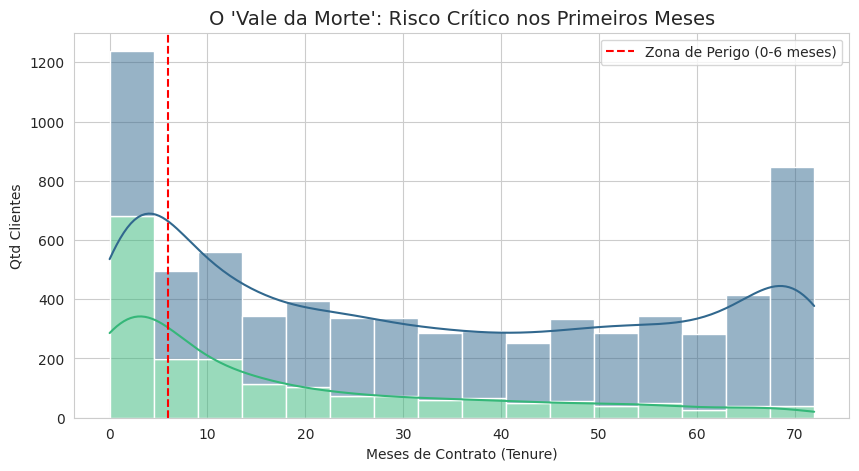


--- 3.2 Análise de Fricção Financeira ---


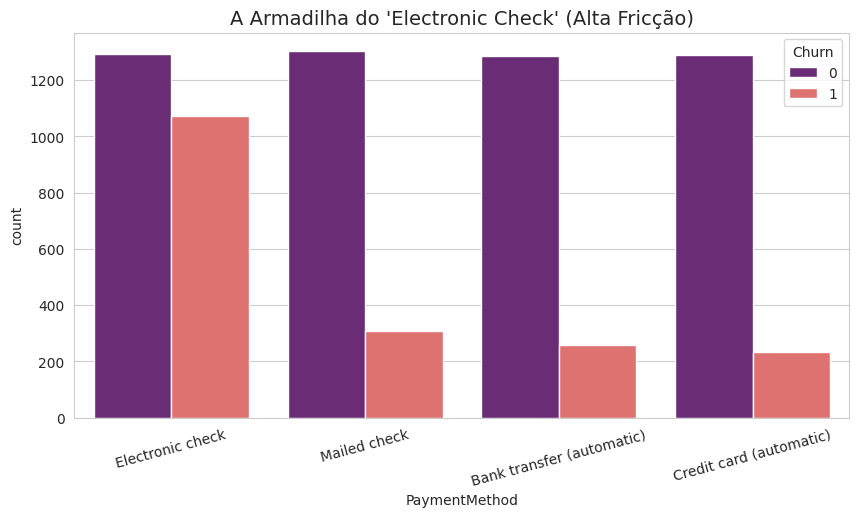

In [8]:
def plot_tenure_risk(df):
    """Visualiza a mortalidade infantil vs lealdade"""
    plt.figure(figsize=(10, 5))
    sns.histplot(data=df, x='tenure', hue='Churn', multiple="stack", kde=True, palette="viridis")
    plt.title("O 'Vale da Morte': Risco Crítico nos Primeiros Meses", fontsize=14)
    plt.xlabel("Meses de Contrato (Tenure)")
    plt.ylabel("Qtd Clientes")
    plt.axvline(x=6, color='red', linestyle='--', label='Zona de Perigo (0-6 meses)')
    plt.legend()
    plt.show()

def plot_payment_friction(df):
    """Analisa a fricção do método de pagamento"""
    plt.figure(figsize=(10, 5))
    sns.countplot(data=df, x='PaymentMethod', hue='Churn', palette="magma")
    plt.title("A Armadilha do 'Electronic Check' (Alta Fricção)", fontsize=14)
    plt.xticks(rotation=15)
    plt.show()

# Executando EDA
print("\n--- 3.1 Análise de Ciclo de Vida ---")
plot_tenure_risk(df)
#: "Vejam esse pico de churn no mês 0-5. Se o cliente sobrevive a isso, ele fica anos."

print("\n--- 3.2 Análise de Fricção Financeira ---")
plot_payment_friction(df)
#: "Electronic Check exige ação manual do usuário todo mês. Isso o faz repensar a compra. Débito automático 'esconde' a dor do pagamento."


In [9]:
# 4. SANKEY DIAGRAM: VISUALIZANDO O "RIO DE SANGUE" (ADVANCED)
# ------------------------------------------------------------------------------
#: Gráficos de barra são estáticos. Sankey mostra fluxo.
# Isso impressiona stakeholders e conta a história da jornada.


In [10]:
import plotly.graph_objects as go

#: Gráficos de barra são estáticos. Sankey mostra fluxo.
# Isso impressiona stakeholders e conta a história da jornada.

def generate_sankey(df, cat_cols=[], value_col='customerID'):
    # Preparação dos dados: Sankey precisa de Source(Index) -> Target(Index) -> Value

    # Criar labels únicos para todos os nós
    label_list = []
    for col in cat_cols:
        label_list.extend(df[col].unique().tolist())

    # Mapear labels para índices inteiros (0, 1, 2...)
    label_map = {label: i for i, label in enumerate(list(set(label_list)))}

    sources = []
    targets = []
    values = []

    # Construir os links par a par (Coluna 1 -> Coluna 2, Coluna 2 -> Coluna 3...)
    for i in range(len(cat_cols) - 1):
        col_source = cat_cols[i]
        col_target = cat_cols[i+1]

        # Agrupar para contar o fluxo
        flow = df.groupby([col_source, col_target])[value_col].count().reset_index()

        for _, row in flow.iterrows():
            sources.append(label_map[row[col_source]])
            targets.append(label_map[row[col_target]])
            values.append(row[value_col])

    # Criar o plot
    fig = go.Figure(data=[go.Sankey(
        node=dict(
            pad=15,
            thickness=20,
            line=dict(color='black', width=0.5),
            label=list(label_map.keys())
        ),
        link=dict(
            source=sources,
            target=targets,
            value=values
        )
    )])

    fig.update_layout(title_text="Fluxo de Churn: Contrato -> Internet -> Pagamento -> Decisão", font_size=10)
    fig.show()

print("\n--- 4. Visualização de Fluxo (Sankey) ---")
#: "Vamos rastrear de onde vêm os cancelamentos. Observem o fluxo 'Month-to-month' -> 'Fiber Optic' -> 'Churn=Yes'."
generate_sankey(df, cat_cols=['Contract', 'InternetService', 'PaymentMethod', 'Churn'])


--- 4. Visualização de Fluxo (Sankey) ---


In [ ]:
# 5. ANÁLISE DE SOBREVIVÊNCIA (DIFERENCIAL TÉCNICO)
# ------------------------------------------------------------------------------
#: Churn não é apenas "SE" sai, mas "QUANDO" sai.
# Regressão Logística ignora o tempo. Survival Analysis modela o risco temporal.


--- 5. Análise de Sobrevivência (Lifelines) ---


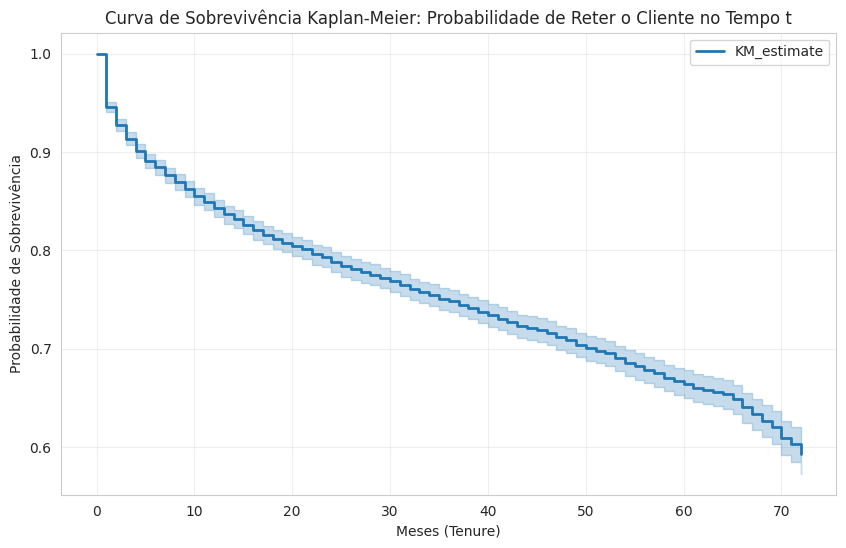

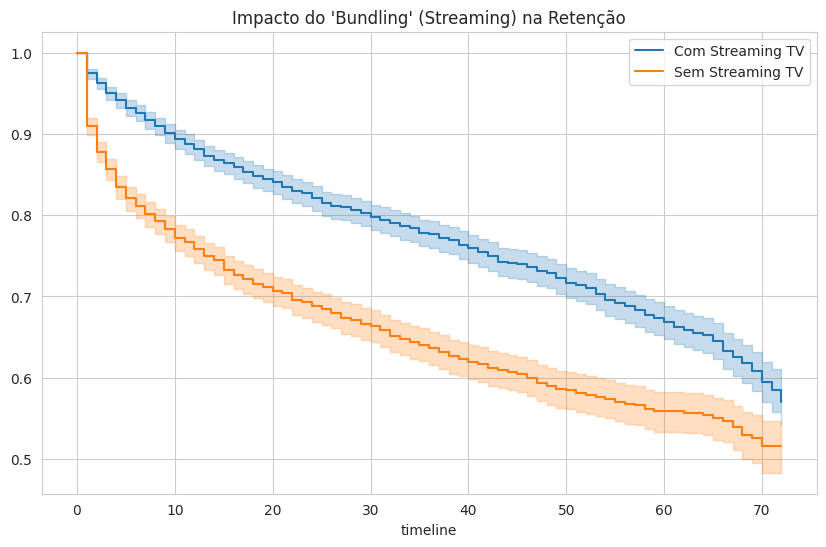


Teste Log-Rank p-value: 0.0000000000
>> CONCLUSÃO ESTATÍSTICA: O serviço de Streaming AUMENTA significativamente a retenção.


In [ ]:
def survival_analysis_demo(df):
    kmf = KaplanMeierFitter()

    # Ajustando o modelo: Tempo (tenure) e Evento (ChurnBinary)
    kmf.fit(durations=df['tenure'], event_observed=df['Churn'])

    plt.figure(figsize=(10, 6))
    kmf.plot_survival_function(linewidth=2)
    plt.title('Curva de Sobrevivência Kaplan-Meier: Probabilidade de Reter o Cliente no Tempo t')
    plt.xlabel('Meses (Tenure)')
    plt.ylabel('Probabilidade de Sobrevivência')
    plt.grid(True, alpha=0.3)
    plt.show()

    # Comparando Coortes: StreamingTV (Sim vs Não)
    # Hipótese: Quem tem serviços agregados (bundling) cancela menos?
    ax = plt.subplot(111)

    treat = df[df['StreamingTV'] == "Yes"]
    control = df[df['StreamingTV'] == "No"]

    kmf.fit(treat['tenure'], event_observed=treat['Churn'], label='Com Streaming TV')
    kmf.plot(ax=ax)

    kmf.fit(control['tenure'], event_observed=control['Churn'], label='Sem Streaming TV')
    kmf.plot(ax=ax)

    plt.title("Impacto do 'Bundling' (Streaming) na Retenção")
    plt.show()

    # Teste Estatístico (Log-Rank) para provar que a diferença é real
    results = logrank_test(treat['tenure'], control['tenure'], event_observed_A=treat['Churn'], event_observed_B=control['Churn'])
    print(f"\nTeste Log-Rank p-value: {results.p_value:.10f}")
    if results.p_value < 0.05:
        print(">> CONCLUSÃO ESTATÍSTICA: O serviço de Streaming AUMENTA significativamente a retenção.")
    else:
        print(">> CONCLUSÃO ESTATÍSTICA: Não há diferença significativa.")

survival_analysis_demo(df)


In [ ]:
# 6. MODELAGEM FINANCEIRA: LTV E RECEITA EM RISCO
# ------------------------------------------------------------------------------
#: O Cientista de Dados precisa falar a língua do CFO: Dinheiro.

In [ ]:
def calculate_simple_ltv(df):
    # LTV Simplificado = (ARPU * Margem) / Churn Rate
    # Vamos assumir uma margem bruta de 70% (típico de telecom)
    GROSS_MARGIN = 0.70

    # Segmentando por Tipo de Contrato
    ltv_data = df.groupby('Contract').agg(
        ARPU=('MonthlyCharges', 'mean'), # ARPU aproximado
        ChurnRate=('Churn', 'mean'),    # Churn Rate
        Count=('customerID', 'count')
    )

    # Cálculo do LTV
    # Evitar divisão por zero se churn for 0 (caso raro, mas bom tratar)
    ltv_data['LTV'] = (ltv_data['ARPU'] * GROSS_MARGIN) / ltv_data['ChurnRate'].replace(0, np.inf)

    print("\n--- 6. Matriz de Valor (LTV) por Contrato ---")
    print(ltv_data.sort_values('LTV', ascending=False))

    #: "Olhem isso. Um cliente de 2 anos tem LTV 10x maior que o mensal.
    # Mover 10% da base mensal para anual vale mais que adquirir 1000 novos clientes."

calculate_simple_ltv(df)


--- 6. Matriz de Valor (LTV) por Contrato ---
                     ARPU  ChurnRate  Count          LTV
Contract                                                
Two year        60.770413   0.028319   1695  1502.168646
One year        65.048608   0.112695   1473   404.045904
Month-to-month  66.398490   0.427097   3875   108.825320
